In [15]:
# ============================================
# Imports Libs
# ============================================
import sys
from pathlib import Path

import warnings
import itertools

import numpy as np
import pandas as pd

import scipy
from scipy import stats

from sklearn import metrics

import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.ticker import FuncFormatter
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap

import seaborn as sns

from IPython.display import display

warnings.filterwarnings("ignore")

# ============================================
# Versions
# ============================================

print("python     =", sys.version.split()[0])
print("pandas     =", pd.__version__)
print("numpy      =", np.__version__)
print("scipy      =", scipy.__version__)
print("matplotlib =", mpl.__version__)
print("seaborn    =", sns.__version__)

python     = 3.11.15
pandas     = 2.3.3
numpy      = 2.4.6
scipy      = 1.17.1
matplotlib = 3.10.9
seaborn    = 0.13.2


In [16]:
# ============================================
# Paths
# ============================================

ROOT_DIR = Path("..")

RESULT_TABLE_DIR = ROOT_DIR / "results" / "table"
RESULT_FIGURE_DIR = ROOT_DIR / "results" / "figures"

RESULT_TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Tables :", RESULT_TABLE_DIR)
print("Figures:", RESULT_FIGURE_DIR)

Tables : ../results/table
Figures: ../results/figures


In [17]:
# ============================================
# Global plotting configuration
# ============================================

_PLOT_CFG = {
    "fig_w": 6.0,
    "fig_h": 5.0,
    "dpi": 300,
}


def set_plot_style(
    *,
    font_size=12,
    dpi=300,
    axes_linewidth=1.0,
    spines_top=False,
    spines_right=False,
    tick_size_major=5,
    tick_dir="out",
    grid=True,
    grid_alpha=0.25,
    fig_w=6.0,
    fig_h=5.0,
):

    sns.set_theme(
        style="whitegrid",
        context="notebook",
    )

    mpl.rcParams.update({

        # fonts
        "font.family": "DejaVu Sans",
        "font.size": font_size,

        # figure
        "figure.dpi": dpi,
        "savefig.dpi": dpi,

        # axes
        "axes.linewidth": axes_linewidth,
        "axes.spines.top": spines_top,
        "axes.spines.right": spines_right,
        "axes.grid": grid,
        "axes.axisbelow": True,

        # grid
        "grid.alpha": grid_alpha,
        "grid.linewidth": 0.7,

        # ticks
        "xtick.major.size": tick_size_major,
        "ytick.major.size": tick_size_major,
        "xtick.direction": tick_dir,
        "ytick.direction": tick_dir,

        # legends
        "legend.frameon": False,

        # savefig
        "savefig.bbox": "tight",
        "savefig.transparent": False,
    })

    _PLOT_CFG.update({
        "fig_w": fig_w,
        "fig_h": fig_h,
        "dpi": dpi,
    })


def make_fig(
    w=None,
    h=None,
    dpi=None,
):
    W = float(w) if w is not None else _PLOT_CFG["fig_w"]
    H = float(h) if h is not None else _PLOT_CFG["fig_h"]
    D = dpi if dpi is not None else _PLOT_CFG["dpi"]

    fig, ax = plt.subplots(
        figsize=(W, H),
        dpi=D,
    )

    return fig, ax


set_plot_style()

In [18]:
# ============================================
# Benchmark plotting configuration
# ============================================

species_order = [
    "AT21",
    "NB21",
    "OS21",
]

model_order = [
    "PLS",
    "Ridge",
    "Lasso",
    "MLP",
    "DecisionTree",
    "RandomForest",
    "XGBoost",
    "LightGBM",
]

setting_order = [
    "default",
    "tuned",
]


# species colors
species_palette = {
    "AT21": "#6c5415",
    "NB21": "#7e3131",
    "OS21": "#13563f",
}


# default vs tuned
setting_palette = {
    "default": "#A0A0A0",
    "tuned": "#A75151",
}


# model colors
model_palette = {
    "PLS": "#8172B3",
    "Ridge": "#4C72B0",
    "Lasso": "#64B5CD",
    "MLP": "#CCB974",
    "DecisionTree": "#DD8452",
    "RandomForest": "#55A868",
    "XGBoost": "#C44E52",
    "LightGBM": "#2E8B57",
}

#Custom heatmap color
DrDb = LinearSegmentedColormap.from_list(
    "DrDb",
    [
        "#06080c",   # dark
        "#FFF9E7",   # light center
        "#910e0e",   # dark red
    ]
)

In [19]:
# ============================================
# Formatting and saving helpers
# ============================================

def metric_formatter(decimals=2):
    return FuncFormatter(lambda x, _pos=None: f"{x:.{decimals}f}")


def compact_formatter(decimals=1):
    def _fmt(x, _pos=None):
        axx = abs(x)

        if axx >= 1e9:
            s = f"{x / 1e9:.{decimals}f}B"
        elif axx >= 1e6:
            s = f"{x / 1e6:.{decimals}f}M"
        elif axx >= 1e3:
            s = f"{x / 1e3:.{decimals}f}k"
        elif axx >= 10:
            s = f"{x:.0f}"
        else:
            s = f"{x:.2f}"

        return (
            s.replace(".0B", "B")
             .replace(".0M", "M")
             .replace(".0k", "k")
        )

    return FuncFormatter(_fmt)


def format_axis(
    ax,
    *,
    xlabel=None,
    ylabel=None,
    title=None,
    x_metric=False,
    y_metric=False,
    x_compact=False,
    y_compact=False,
    rotate_xticks=0,
):
    if xlabel is not None:
        ax.set_xlabel(xlabel)

    if ylabel is not None:
        ax.set_ylabel(ylabel)

    if title is not None:
        ax.set_title(title, pad=10)

    if x_metric:
        ax.xaxis.set_major_formatter(metric_formatter())

    if y_metric:
        ax.yaxis.set_major_formatter(metric_formatter())

    if x_compact:
        ax.xaxis.set_major_formatter(compact_formatter())

    if y_compact:
        ax.yaxis.set_major_formatter(compact_formatter())

    if rotate_xticks:
        ax.tick_params(axis="x", rotation=rotate_xticks)

    return ax


def save_fig(fig, filename):
    RESULT_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

    path = RESULT_FIGURE_DIR / filename

    fig.savefig(
        path,
        bbox_inches="tight",
    )

    print(path)
    return path

In [20]:
# ============================================
# Load benchmark results
# ============================================

benchmark_file = RESULT_TABLE_DIR / "benchmark.tsv"

print(benchmark_file)
print("exists:", benchmark_file.exists())

benchmark_results_df = pd.read_csv(
    benchmark_file,
    sep="\t",
)

print(benchmark_results_df.shape)
display(benchmark_results_df.head())

../results/table/benchmark.tsv
exists: True
(48, 14)


,species,model,setting,CV_R2,CV_R2_sd,Train_R2,Test_R2,Train_Pearson_r,Test_Pearson_r,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,best_params
0,AT21,PLS,default,0.152271,0.034206,0.217031,0.178716,0.465866,0.424369,0.884855,0.911727,0.686262,0.716301,NaN
1,AT21,Ridge,default,0.170467,0.034620,0.288948,0.198109,0.537545,0.452137,0.843239,0.900898,0.652107,0.701203,NaN
2,AT21,Lasso,default,0.180112,0.031340,0.274173,0.199704,0.524158,0.449291,0.851955,0.900002,0.657953,0.703148,NaN
3,AT21,MLP,default,-0.025737,0.069512,0.868831,0.030765,0.932350,0.469156,0.362173,0.990450,0.239452,0.737132,NaN
4,AT21,DecisionTree,default,-0.289896,0.077506,0.999884,-0.240557,0.999942,0.399483,0.010763,1.120538,0.000357,0.828674,NaN


In [21]:
# ============================================
# Sanity check and column ordering
# ============================================

expected_cols = [
    "species",
    "model",
    "setting",
    "CV_R2",
    "CV_R2_sd",
    "Train_R2",
    "Test_R2",
    "Train_Pearson_r",
    "Test_Pearson_r",
    "Train_RMSE",
    "Test_RMSE",
    "Train_MAE",
    "Test_MAE",
]

missing_cols = [
    c for c in expected_cols
    if c not in benchmark_results_df.columns
]

print("missing columns:", missing_cols)
print("n rows:", len(benchmark_results_df))
print("species:", benchmark_results_df["species"].unique())
print("models:", benchmark_results_df["model"].unique())
print("settings:", benchmark_results_df["setting"].unique())

benchmark_results_df = benchmark_results_df[expected_cols].copy()

benchmark_results_df["species"] = pd.Categorical(
    benchmark_results_df["species"],
    categories=species_order,
    ordered=True,
)

benchmark_results_df["model"] = pd.Categorical(
    benchmark_results_df["model"],
    categories=model_order,
    ordered=True,
)

benchmark_results_df["setting"] = pd.Categorical(
    benchmark_results_df["setting"],
    categories=setting_order,
    ordered=True,
)

benchmark_results_df = benchmark_results_df.sort_values(
    ["species", "model", "setting"]
).reset_index(drop=True)

display(benchmark_results_df)

missing columns: []
n rows: 48
species: ['AT21' 'NB21' 'OS21']
models: ['PLS' 'Ridge' 'Lasso' 'MLP' 'DecisionTree' 'RandomForest' 'XGBoost'
 'LightGBM']
settings: ['default' 'tuned']


,species,model,setting,CV_R2,CV_R2_sd,Train_R2,Test_R2,Train_Pearson_r,Test_Pearson_r,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE
0,AT21,PLS,default,0.152271,0.034206,0.217031,0.178716,0.465866,0.424369,0.884855,0.911727,0.686262,0.716301
1,AT21,PLS,tuned,0.167010,NaN,0.275754,0.190609,0.525123,0.443101,0.851026,0.905102,0.657794,0.704225
2,AT21,Ridge,default,0.170467,0.034620,0.288948,0.198109,0.537545,0.452137,0.843239,0.900898,0.652107,0.701203
3,AT21,Ridge,tuned,0.178043,NaN,0.260004,0.198809,0.511346,0.447143,0.860230,0.900505,0.665015,0.704720
4,AT21,Lasso,default,0.180112,0.031340,0.274173,0.199704,0.524158,0.449291,0.851955,0.900002,0.657953,0.703148
5,AT21,Lasso,tuned,0.181505,NaN,0.264091,0.200160,0.515073,0.448865,0.857851,0.899746,0.663129,0.704072
6,AT21,MLP,default,-0.025737,0.069512,0.868831,0.030765,0.932350,0.469156,0.362173,0.990450,0.239452,0.737132
7,AT21,MLP,tuned,0.186666,NaN,0.417500,0.238436,0.647285,0.496220,0.763217,0.877953,0.588229,0.666549
8,AT21,DecisionTree,default,-0.289896,0.077506,0.999884,-0.240557,0.999942,0.399483,0.010763,1.120538,0.000357,0.828674
9,AT21,DecisionTree,tuned,0.099047,NaN,0.204733,0.124738,0.452474,0.362067,0.891778,0.941211,0.696083,0.741939


In [22]:
# ============================================
# Main metric table: Test R2
# ============================================

test_r2_table = benchmark_results_df.pivot_table(
    index=["species", "model"],
    columns="setting",
    values="Test_R2",
    observed=False,
).reset_index()

test_r2_table["delta_tuned_minus_default"] = (
    test_r2_table["tuned"] - test_r2_table["default"]
)

display(test_r2_table)

setting,species,model,default,tuned,delta_tuned_minus_default
0,AT21,PLS,0.178716,0.190609,0.011893
1,AT21,Ridge,0.198109,0.198809,0.000700
2,AT21,Lasso,0.199704,0.200160,0.000456
3,AT21,MLP,0.030765,0.238436,0.207670
4,AT21,DecisionTree,-0.240557,0.124738,0.365295
5,AT21,RandomForest,0.273023,0.297555,0.024532
6,AT21,XGBoost,0.277110,0.280060,0.002950
7,AT21,LightGBM,0.278224,0.298263,0.020039
8,NB21,PLS,0.184457,0.227468,0.043011
9,NB21,Ridge,0.235310,0.212692,-0.022618


In [23]:
# ============================================
# Ranking by Test R2
# ============================================

benchmark_rank_df = (
    benchmark_results_df
    .sort_values(
        ["species", "Test_R2"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

display(
    benchmark_rank_df[
        [
            "species",
            "model",
            "setting",
            "Test_R2",
            "Test_Pearson_r",
            "Test_RMSE",
            "Test_MAE",
        ]
    ]
)

,species,model,setting,Test_R2,Test_Pearson_r,Test_RMSE,Test_MAE
0,AT21,LightGBM,tuned,0.298263,0.548332,0.842763,0.643657
1,AT21,RandomForest,tuned,0.297555,0.547742,0.843188,0.641270
2,AT21,XGBoost,tuned,0.280060,0.530780,0.853623,0.652880
3,AT21,LightGBM,default,0.278224,0.537620,0.854711,0.644343
4,AT21,XGBoost,default,0.277110,0.535545,0.855371,0.644559
5,AT21,RandomForest,default,0.273023,0.541205,0.857785,0.642146
6,AT21,MLP,tuned,0.238436,0.496220,0.877953,0.666549
7,AT21,Lasso,tuned,0.200160,0.448865,0.899746,0.704072
8,AT21,Lasso,default,0.199704,0.449291,0.900002,0.703148
9,AT21,Ridge,tuned,0.198809,0.447143,0.900505,0.704720


In [24]:
# ============================================
# Best model per species
# ============================================

best_model_df = (
    benchmark_results_df
    .sort_values(
        ["species", "Test_R2"],
        ascending=[True, False],
    )
    .groupby("species", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

display(
    best_model_df[
        [
            "species",
            "model",
            "setting",
            "Test_R2",
            "Test_Pearson_r",
            "Test_RMSE",
            "Test_MAE",
        ]
    ]
)

,species,model,setting,Test_R2,Test_Pearson_r,Test_RMSE,Test_MAE
0,AT21,LightGBM,tuned,0.298263,0.548332,0.842763,0.643657
1,NB21,RandomForest,tuned,0.295569,0.544706,0.854956,0.647377
2,OS21,XGBoost,tuned,0.389587,0.625976,0.764667,0.578647


In [25]:
# ============================================
# Benchmark summary statistics
# ============================================

summary_df = (
    benchmark_results_df
    .groupby(
        ["species", "setting"],
        observed=False,
    )
    .agg(
        mean_Test_R2=("Test_R2", "mean"),
        max_Test_R2=("Test_R2", "max"),
        min_Test_R2=("Test_R2", "min"),

        mean_Pearson=("Test_Pearson_r", "mean"),
        max_Pearson=("Test_Pearson_r", "max"),

        mean_RMSE=("Test_RMSE", "mean"),
        mean_MAE=("Test_MAE", "mean"),
    )
    .reset_index()
)

display(summary_df)

,species,setting,mean_Test_R2,max_Test_R2,min_Test_R2,mean_Pearson,max_Pearson,mean_RMSE,mean_MAE
0,AT21,default,0.149387,0.278224,-0.240557,0.476101,0.541205,0.923935,0.702188
1,AT21,tuned,0.228579,0.298263,0.124738,0.478031,0.548332,0.883011,0.682414
2,NB21,default,0.149202,0.273894,-0.229699,0.482977,0.541141,0.935293,0.708555
3,NB21,tuned,0.241217,0.295569,0.151914,0.494995,0.544706,0.886933,0.677879
4,OS21,default,0.232390,0.367548,-0.056343,0.539767,0.620830,0.854458,0.651187
5,OS21,tuned,0.303124,0.389587,0.229689,0.557174,0.625976,0.816102,0.627823


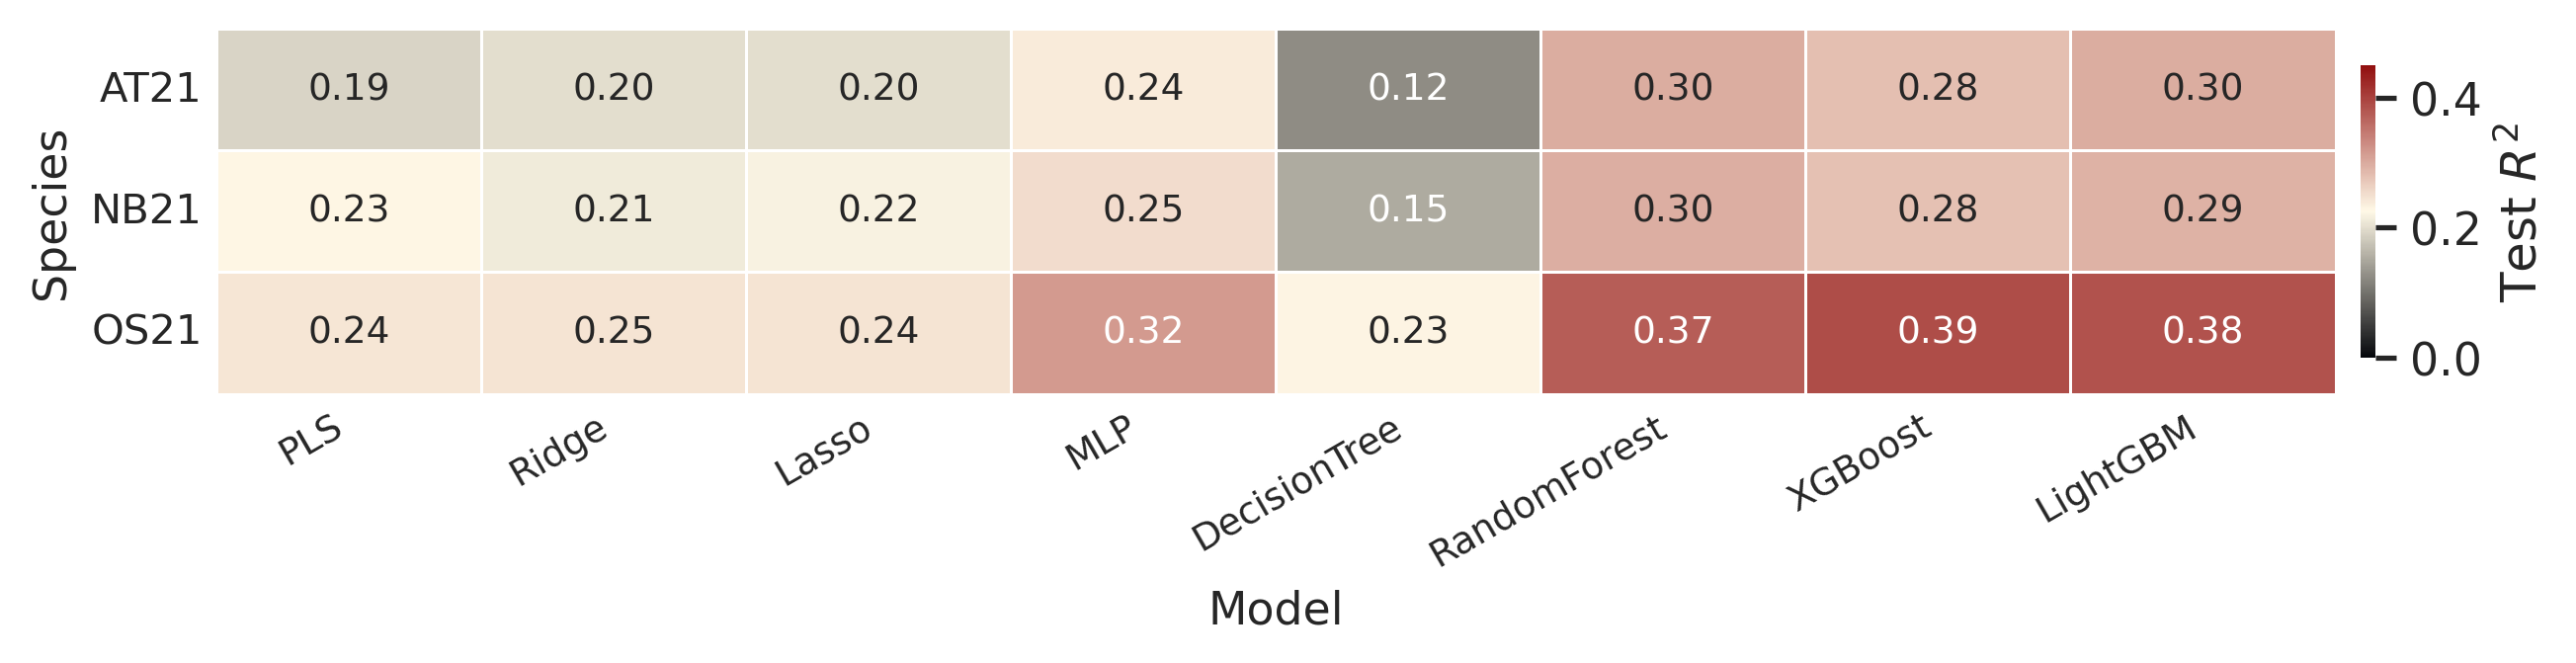

In [26]:
# ============================================
# Figure: Test R2 heatmap
# ============================================

heatmap_df = (
    benchmark_results_df
    .query("setting == 'tuned'")
    .pivot(
        index="species",
        columns="model",
        values="Test_R2",
    )
    .loc[species_order, model_order]
)

fig, ax = make_fig(
    w=9.5,
    h=2.4,
)

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".2f",
    cmap=DrDb,
    vmin=0,
    vmax=0.45,
    linewidths=0.6,
    linecolor="white",
    annot_kws={
        "fontsize": 9,
    },
    cbar_kws={
        "label": r"Test $R^2$",
        "shrink": 0.80,
        "pad": 0.01,
    },
    ax=ax,
)

format_axis(
    ax,
    xlabel="Model",
    ylabel="Species",
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=30,
    ha="right",
    fontsize=9,
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=10,
)

ax.set_xlabel("Model", fontsize=11)
ax.set_ylabel("Species", fontsize=11)

ax.tick_params(axis="both", length=0)

plt.tight_layout()
plt.show()

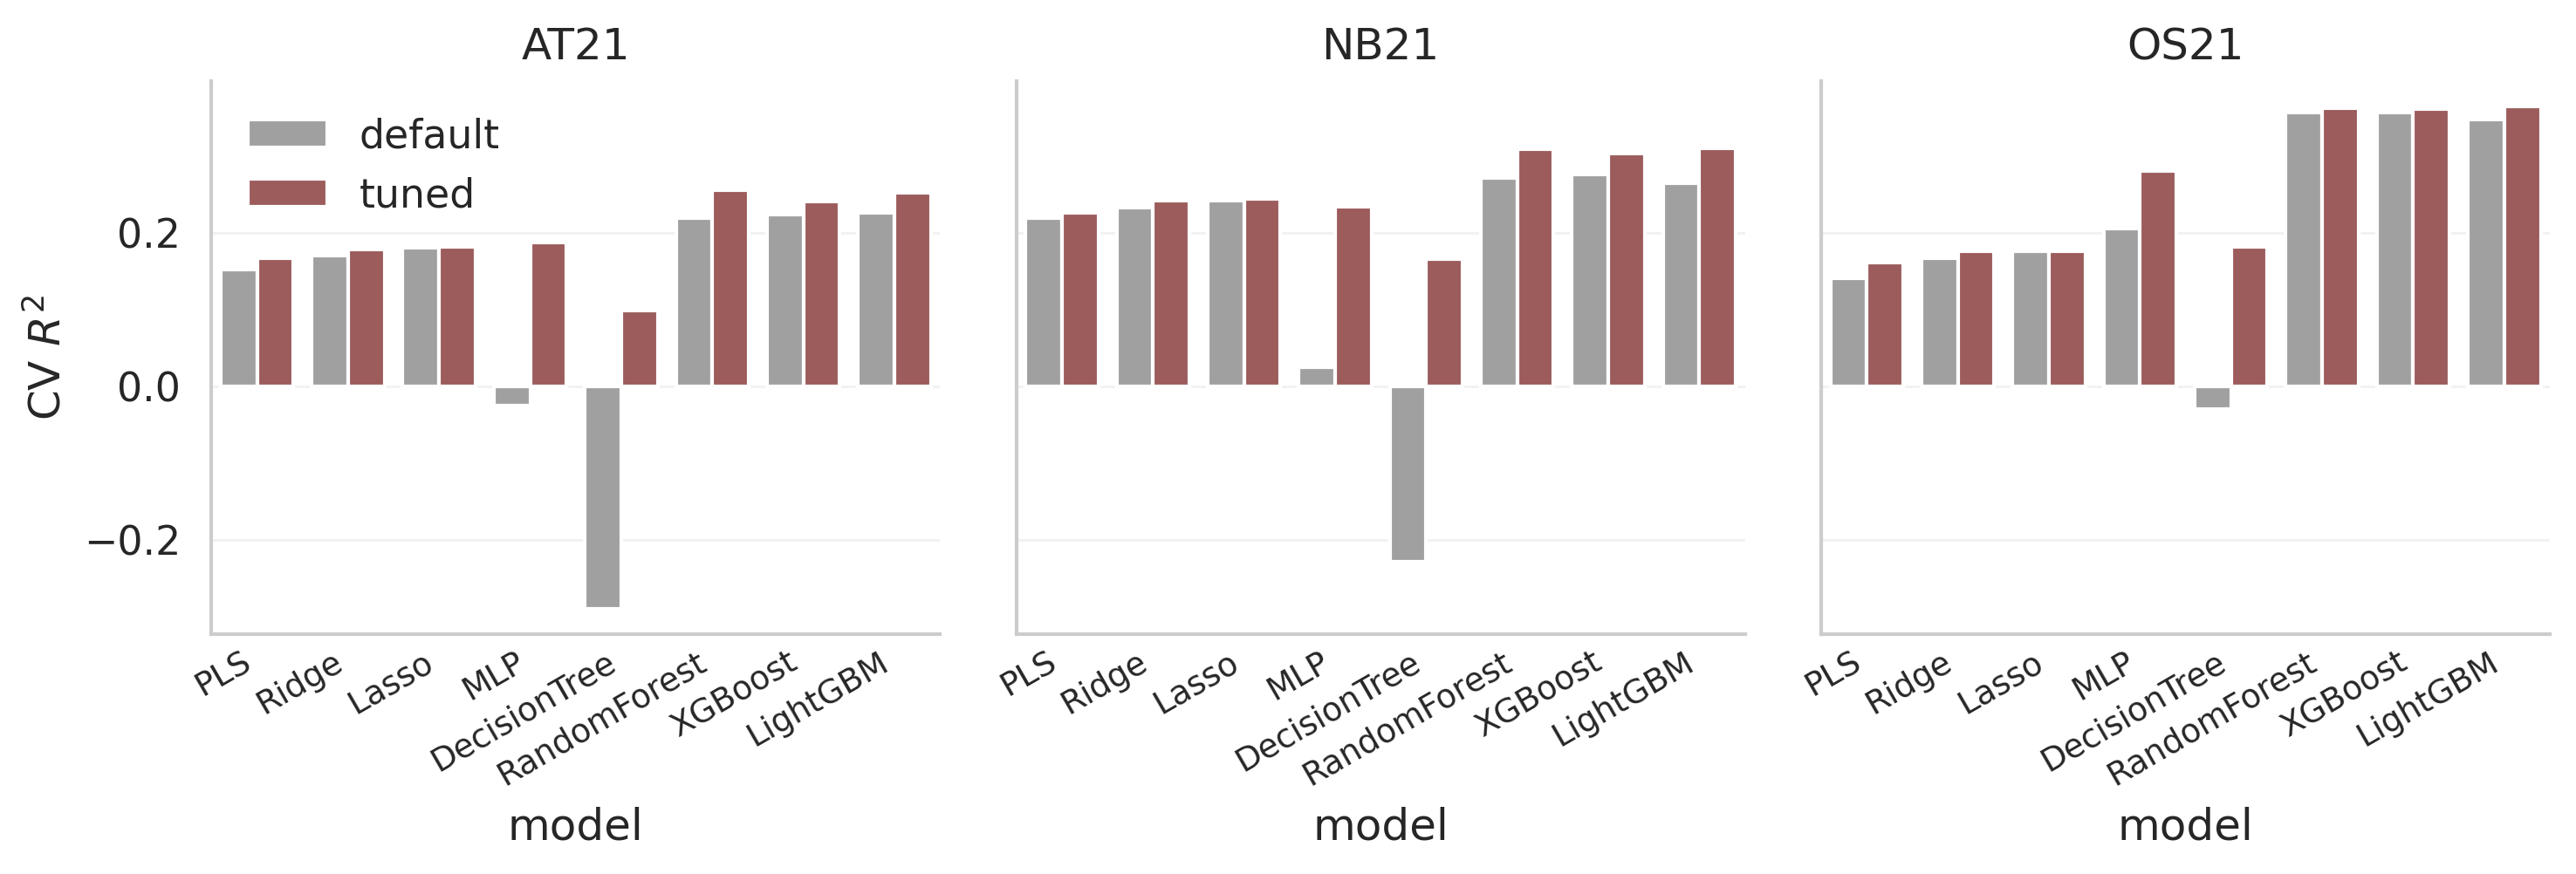

In [27]:
# ============================================
# Figure: Default vs Tuned CV R2
# ============================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(10, 3.5),
    sharey=True,
)

for ax, species in zip(axes, species_order):

    temp_df = (
        benchmark_results_df
        .query("species == @species")
        .copy()
    )

    sns.barplot(
        data=temp_df,
        x="model",
        y="CV_R2",
        hue="setting",
        palette=setting_palette,
        ax=ax,
        errorbar=None,
    )

    ax.set_title(species, fontsize=12)

    format_axis(
        ax,
        xlabel=None,
        ylabel=r"CV $R^2$" if species == species_order[0] else None,
    )

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=30,
        ha="right",
        fontsize=9,
    )

    ax.tick_params(axis="x", length=0)

    if species != species_order[0] and ax.legend_ is not None:
        ax.legend_.remove()

axes[0].legend(
    title=None,
    frameon=False,
    loc="upper left",
)

plt.tight_layout()
plt.show()